# 7. Human Face Anatomy (Eyes, Nose, Lips Structure)

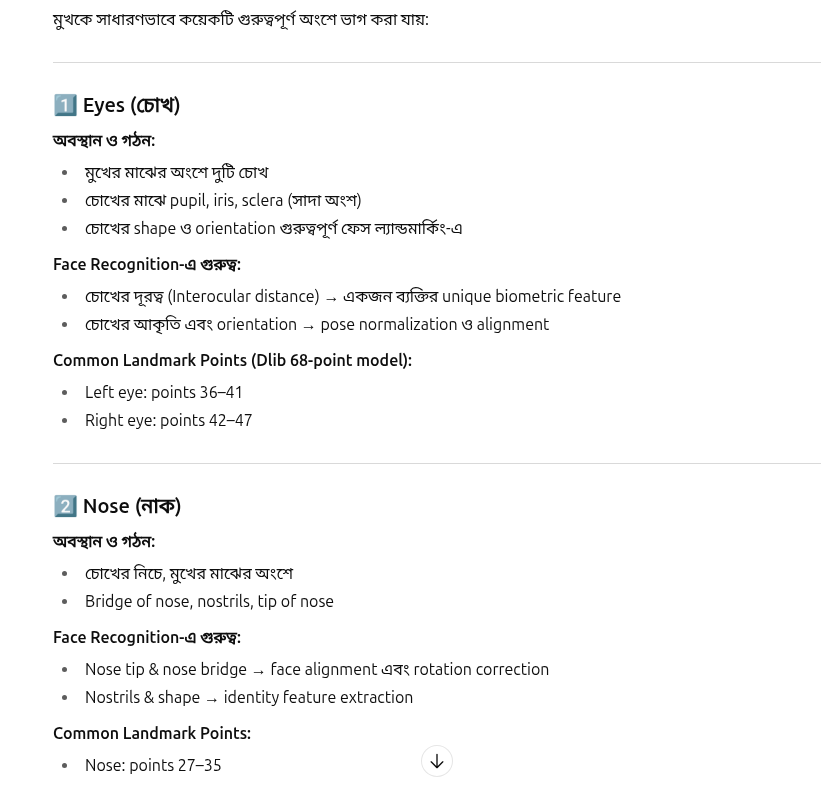

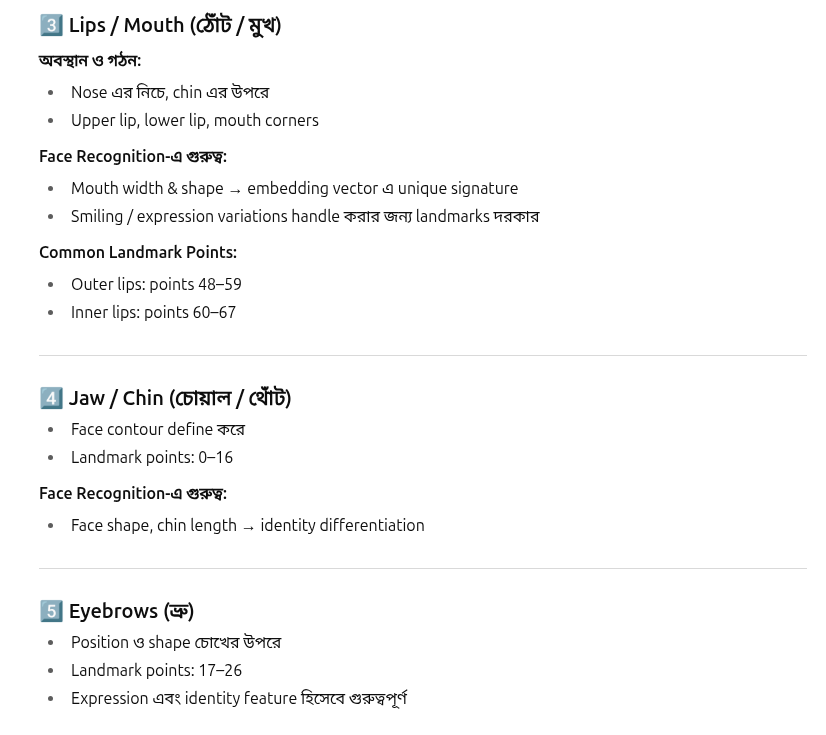

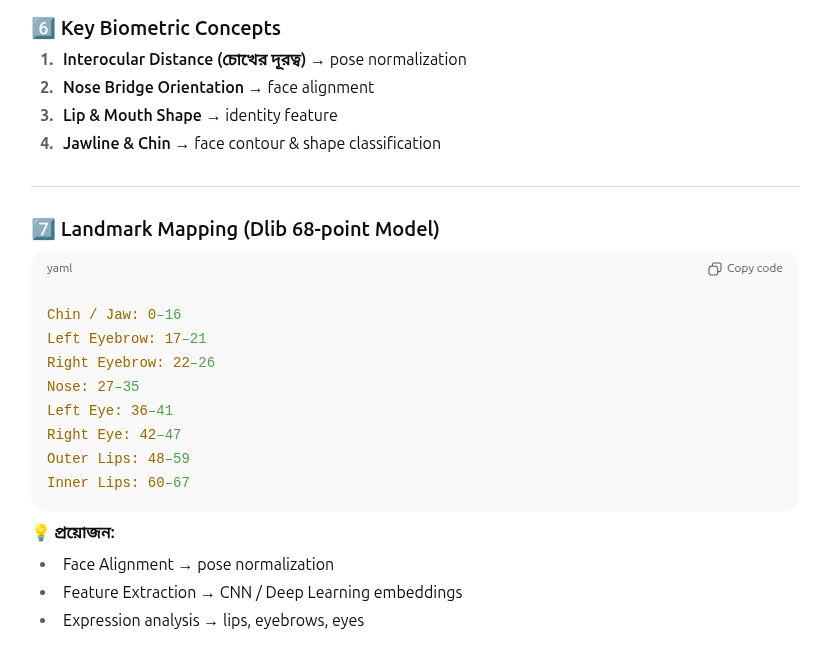

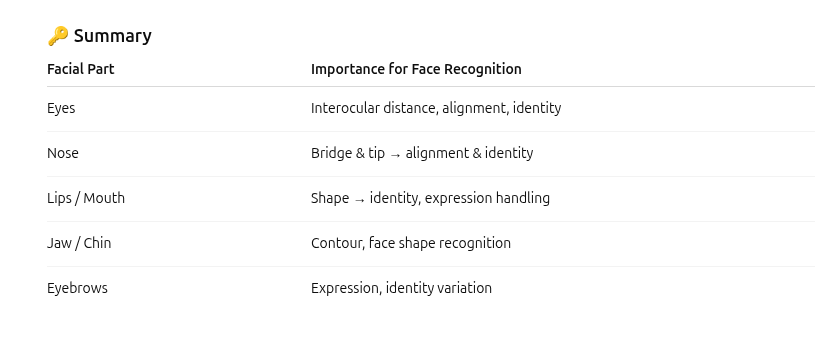

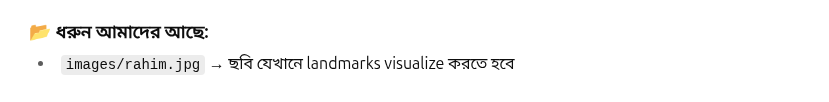

In [1]:
import cv2
import dlib

In [4]:
# Load image
image_path = "../dataset/test/bellingham.jpg"
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [5]:
# Load face detector and landmark predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")  # Dlib pre-trained model

In [6]:
# Detect faces
faces = detector(gray)

for face in faces:
    # Draw rectangle around face
    x, y, w, h = face.left(), face.top(), face.width(), face.height()
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    # Detect landmarks
    landmarks = predictor(gray, face)
    
    # Draw landmarks
    for n in range(0, 68):
        x_point = landmarks.part(n).x
        y_point = landmarks.part(n).y
        cv2.circle(image, (x_point, y_point), 2, (0, 0, 255), -1)

In [7]:
# Show image
cv2.imshow("Face Landmarks", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

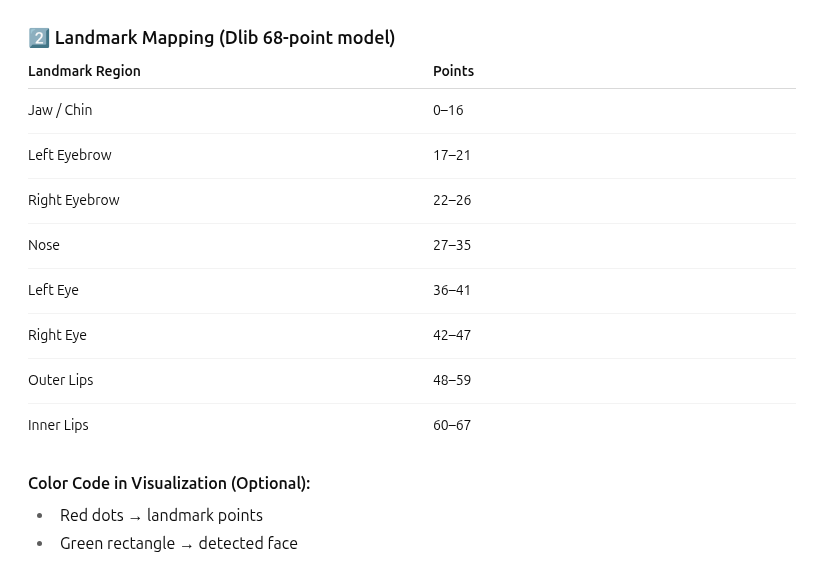

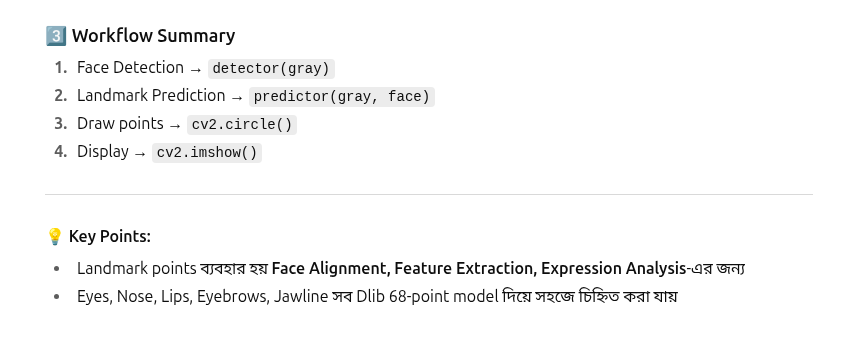

# 8. RGB, HSV, LAB Color Space ধারণা

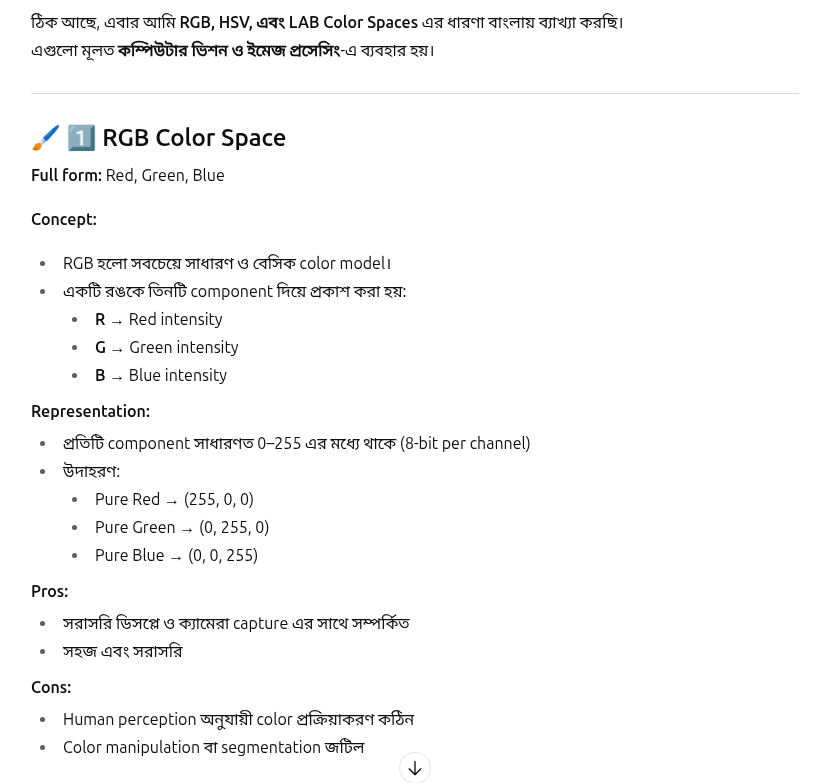

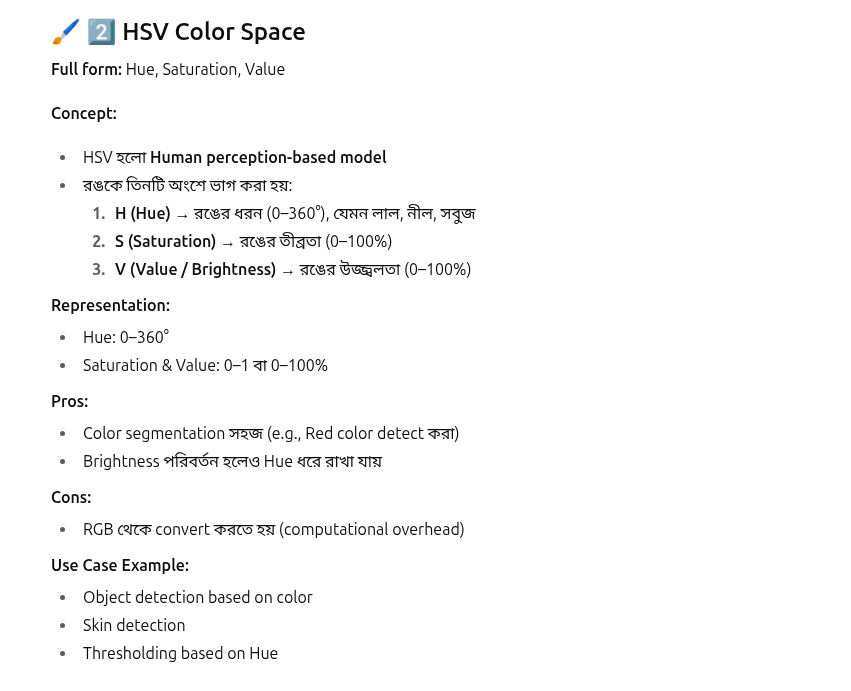

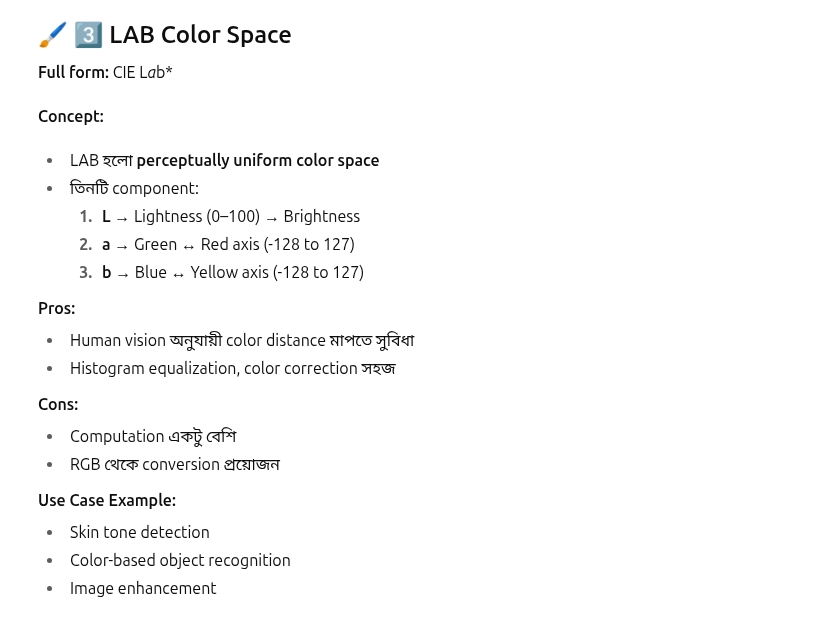

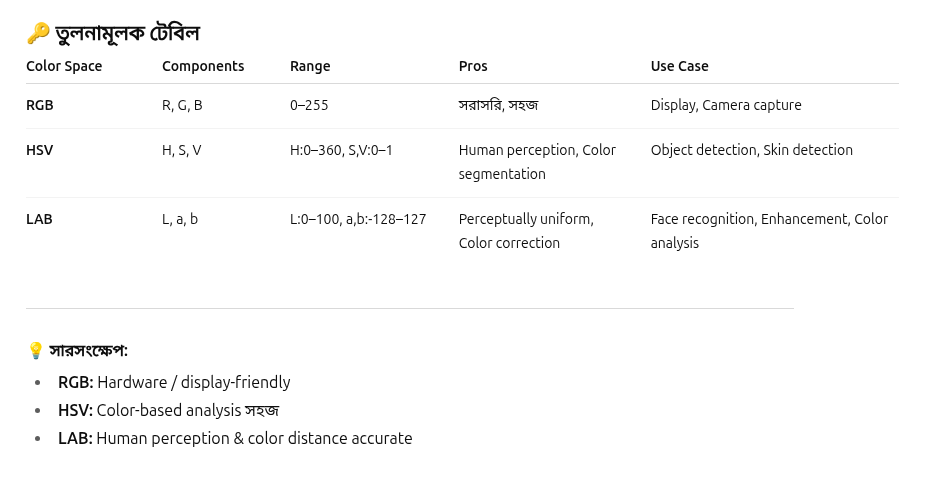

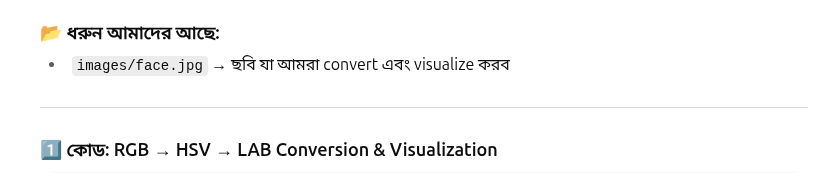

In [8]:
import cv2
import matplotlib.pyplot as plt

In [9]:
# Load image
image = cv2.imread("../dataset/test/bellingham.jpg")
# OpenCV লোড করলে default BGR, তাই RGB এ convert
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [10]:
# Convert to HSV
image_hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

In [11]:
# Convert to LAB
image_lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)

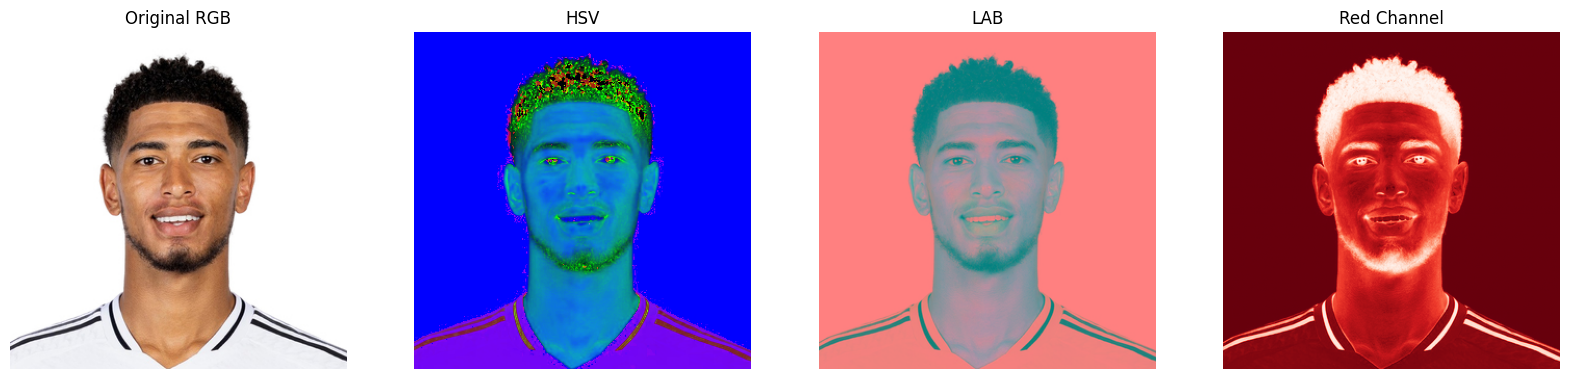

In [12]:
# Plot Original & Color Spaces
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("Original RGB")
axes[0].axis('off')

axes[1].imshow(image_hsv)
axes[1].set_title("HSV")
axes[1].axis('off')

axes[2].imshow(image_lab)
axes[2].set_title("LAB")
axes[2].axis('off')

# Optionally show separate channels of RGB
r, g, b = cv2.split(image_rgb)
axes[3].imshow(r, cmap='Reds')
axes[3].set_title("Red Channel")
axes[3].axis('off')

plt.show()

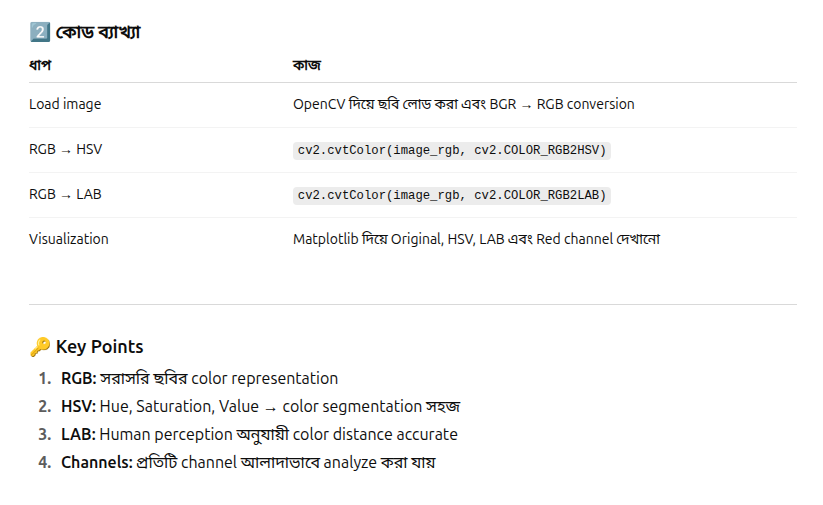

# 9. Image Pixel, Matrix & Channels (1D, 2D, 3D Array)

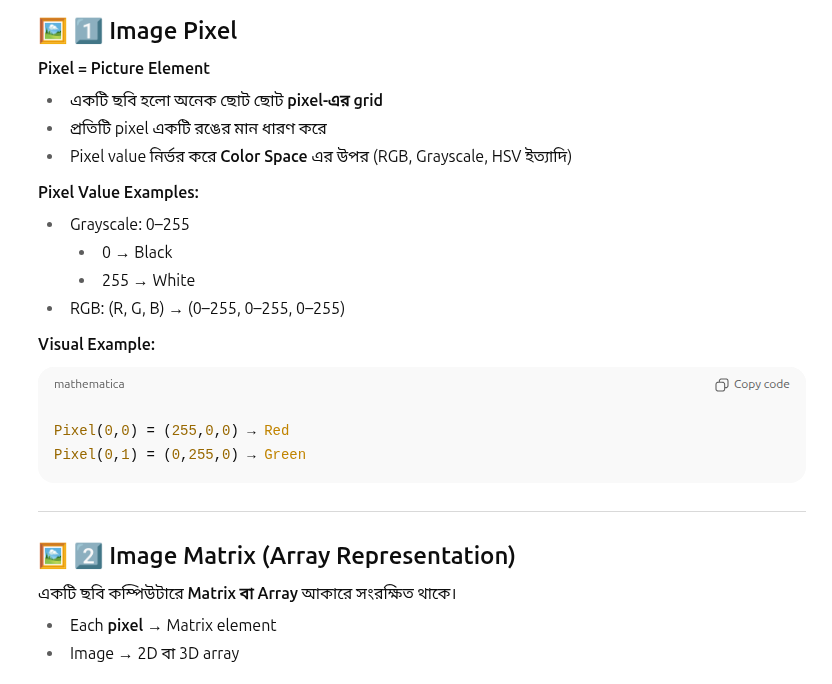

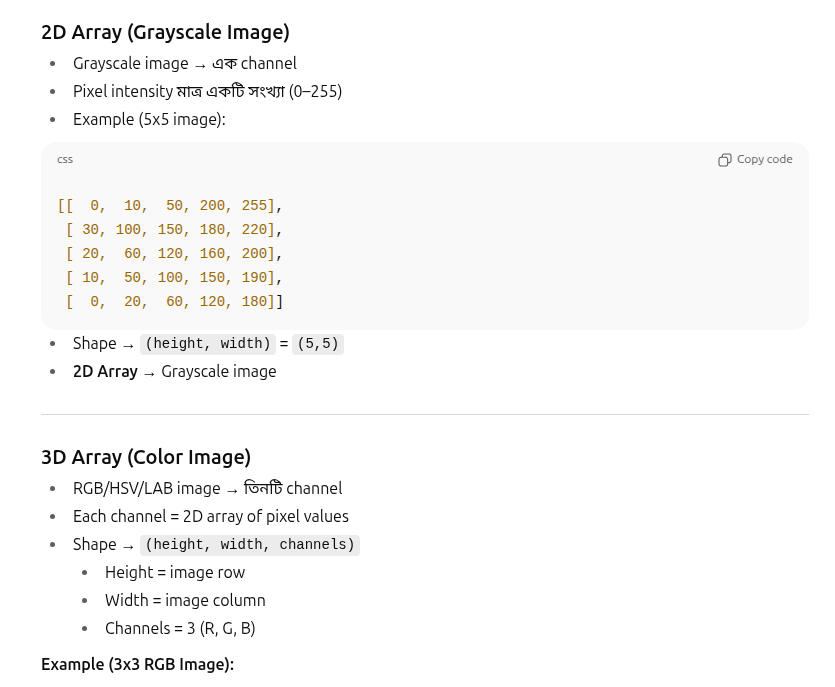

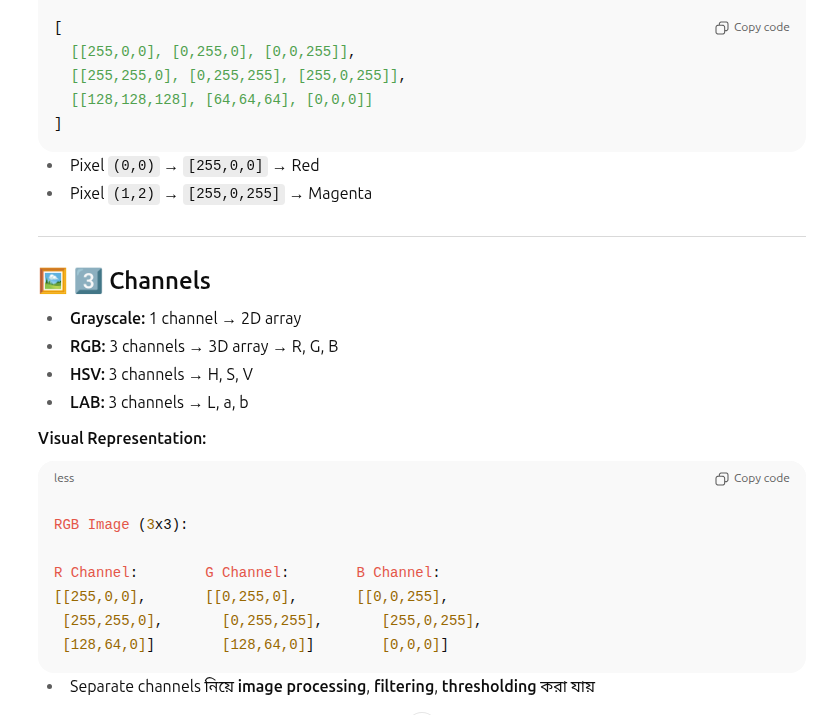

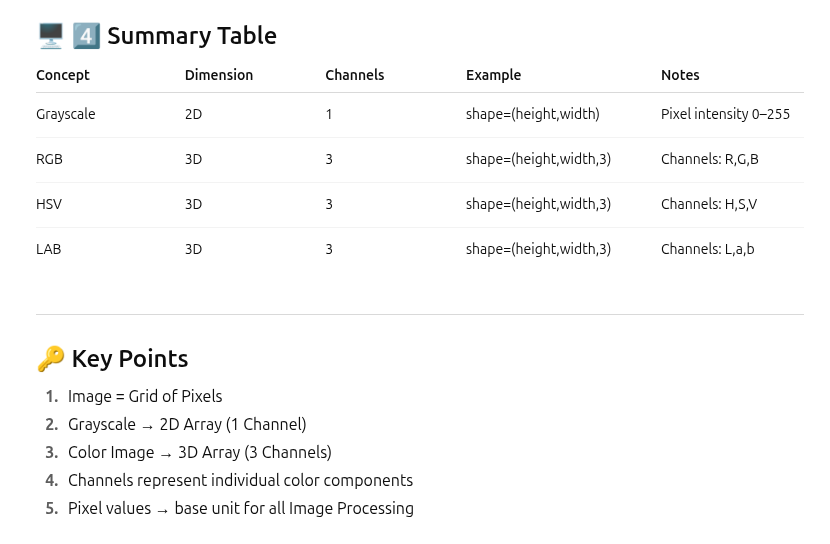

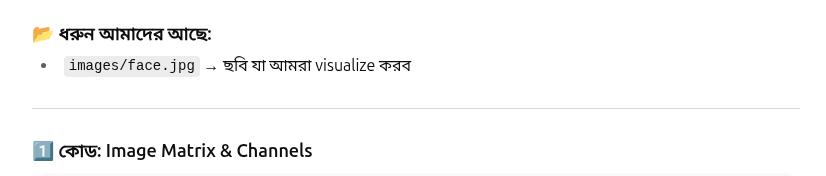

RGB Image Shape: (324, 324, 3)
Grayscale Image Shape: (324, 324)
R Channel shape: (324, 324)
G Channel shape: (324, 324)
B Channel shape: (324, 324)


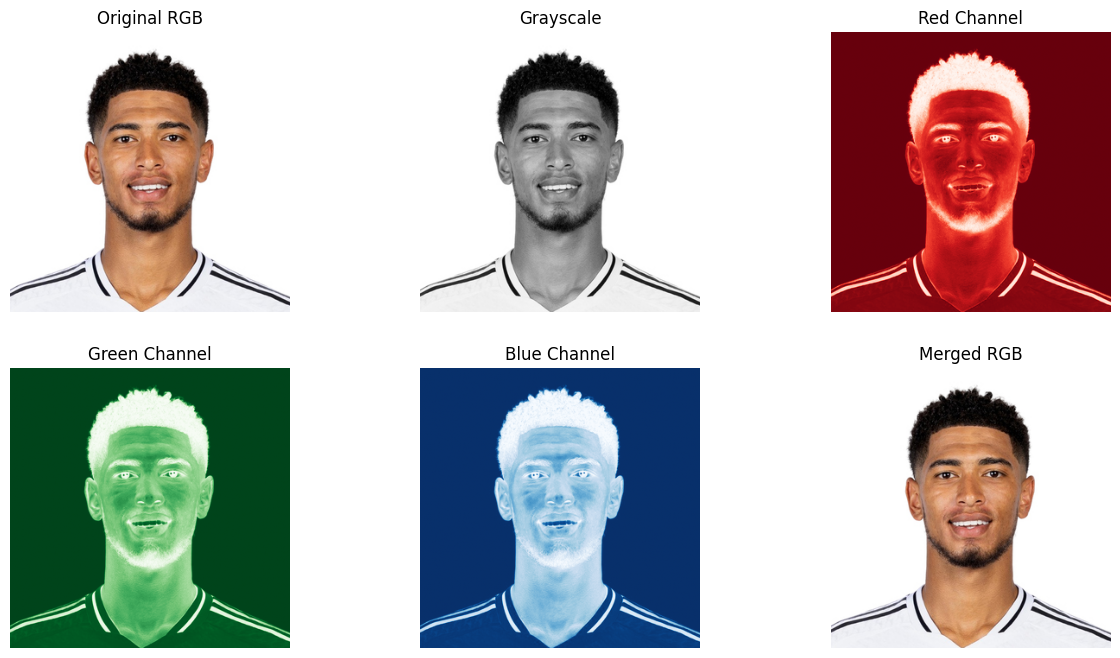

In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load Image
image = cv2.imread("../dataset/test/bellingham.jpg")        # OpenCV loads BGR
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# Print Shapes
print("RGB Image Shape:", image_rgb.shape)   # (height, width, 3)
print("Grayscale Image Shape:", gray.shape)  # (height, width)


# Split RGB Channels
R, G, B = cv2.split(image_rgb)
print("R Channel shape:", R.shape)
print("G Channel shape:", G.shape)
print("B Channel shape:", B.shape)


# Visualize Images and Channels
fig, axes = plt.subplots(2,3, figsize=(15,8))

axes[0,0].imshow(image_rgb)
axes[0,0].set_title("Original RGB")
axes[0,0].axis('off')

axes[0,1].imshow(gray, cmap='gray')
axes[0,1].set_title("Grayscale")
axes[0,1].axis('off')

axes[0,2].imshow(R, cmap='Reds')
axes[0,2].set_title("Red Channel")
axes[0,2].axis('off')

axes[1,0].imshow(G, cmap='Greens')
axes[1,0].set_title("Green Channel")
axes[1,0].axis('off')

axes[1,1].imshow(B, cmap='Blues')
axes[1,1].set_title("Blue Channel")
axes[1,1].axis('off')

# Optional: Combine channels back to RGB
merged = cv2.merge([R, G, B])
axes[1,2].imshow(merged)
axes[1,2].set_title("Merged RGB")
axes[1,2].axis('off')

plt.show()

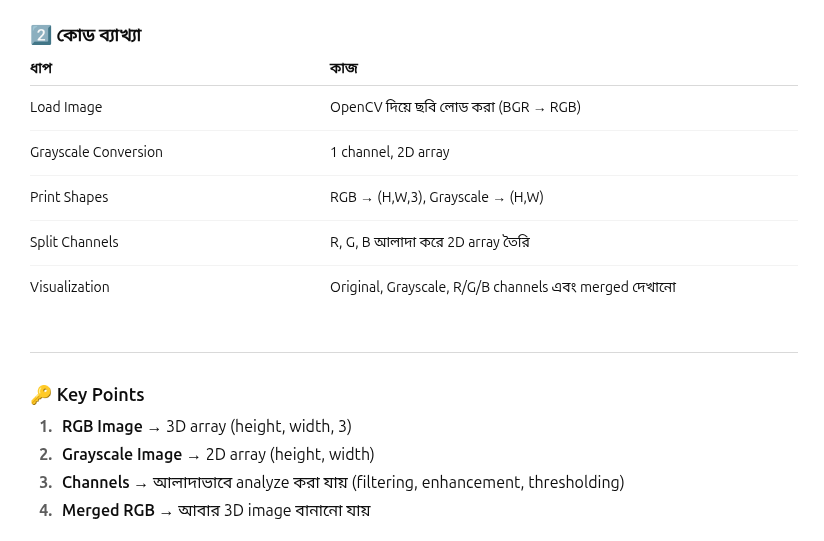

# 10. Grayscale Conversion

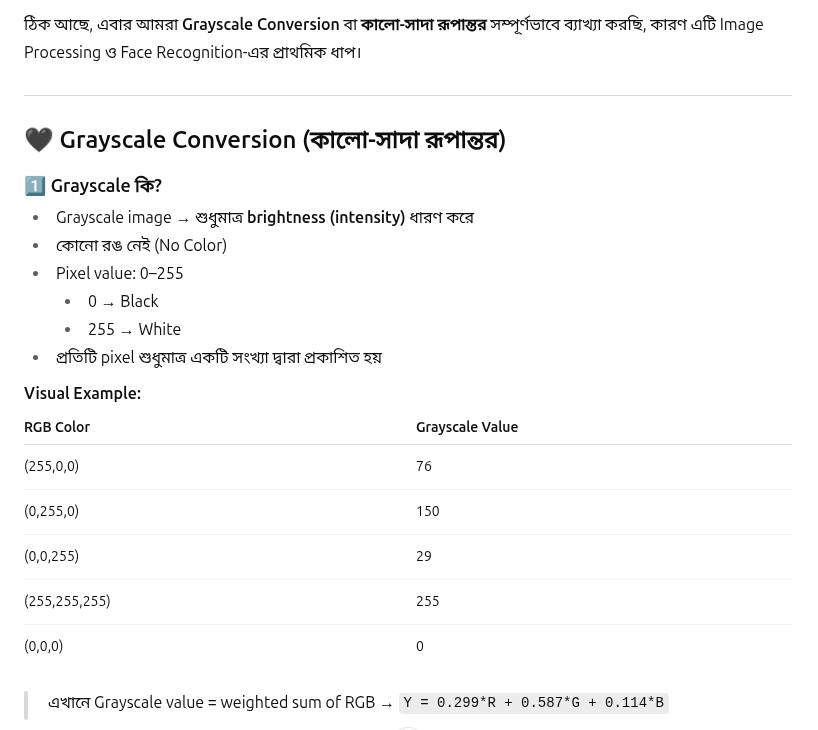

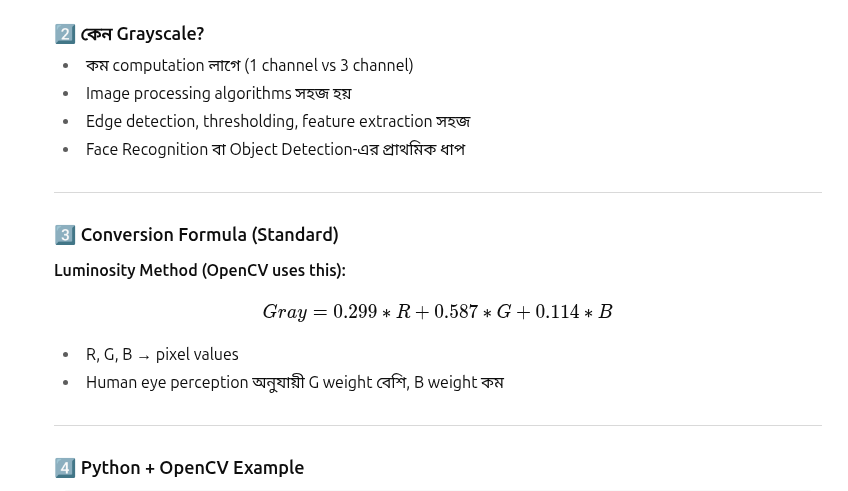

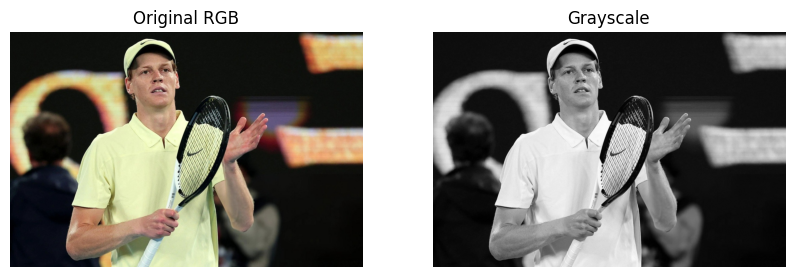

In [14]:
import cv2
import matplotlib.pyplot as plt

# Load color image
image = cv2.imread("../dataset/test/sinner.jpeg")  # OpenCV loads BGR
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display images
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original RGB")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

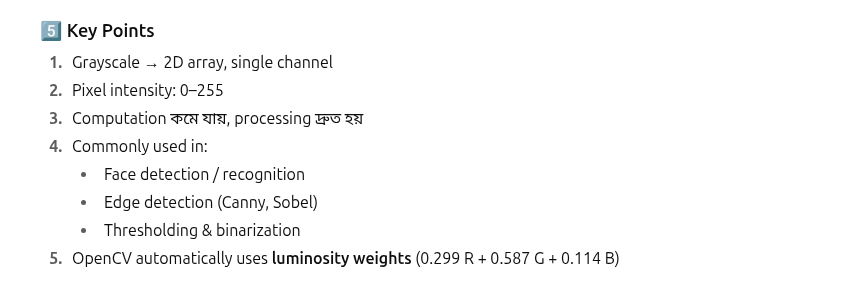

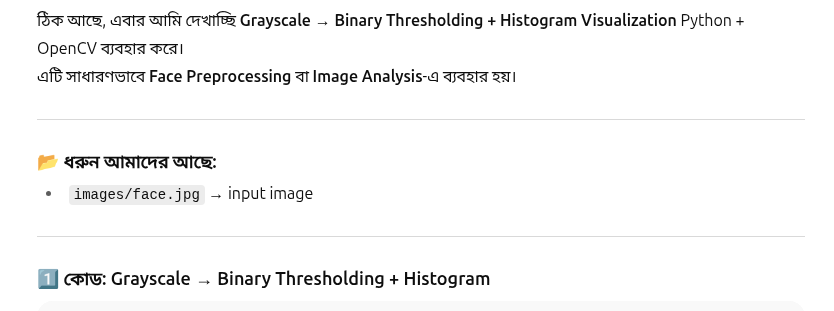

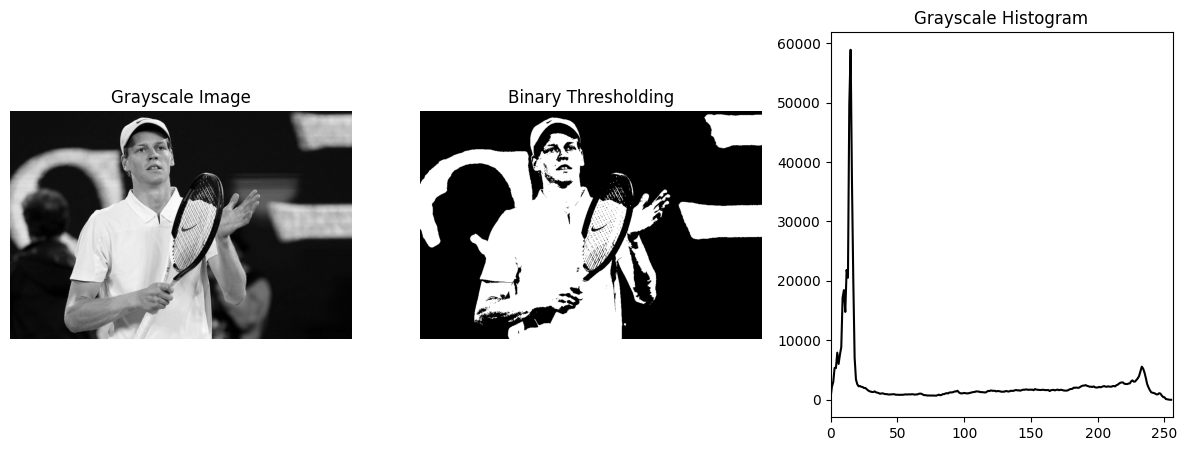

In [15]:
import cv2
import matplotlib.pyplot as plt


# Load Image and Convert to Grayscale
image = cv2.imread("../dataset/test/sinner.jpeg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# Binary Thresholding
# Threshold value = 127, max_value = 255
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)


# Histogram of Grayscale Image
hist = cv2.calcHist([gray], [0], None, [256], [0,256])

# Visualization
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(binary, cmap='gray')
plt.title("Binary Thresholding")
plt.axis('off')

plt.subplot(1,3,3)
plt.plot(hist, color='black')
plt.title("Grayscale Histogram")
plt.xlim([0,256])

plt.show()

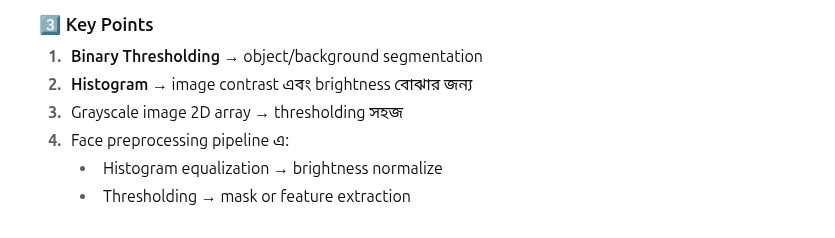

# 11. Image Resolution, DPI, Aspect Ratio

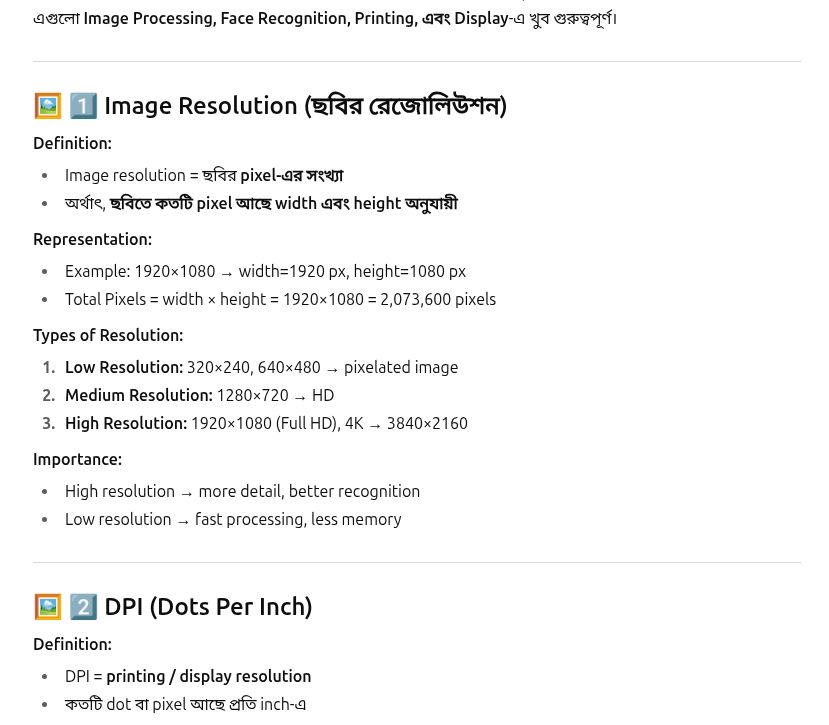

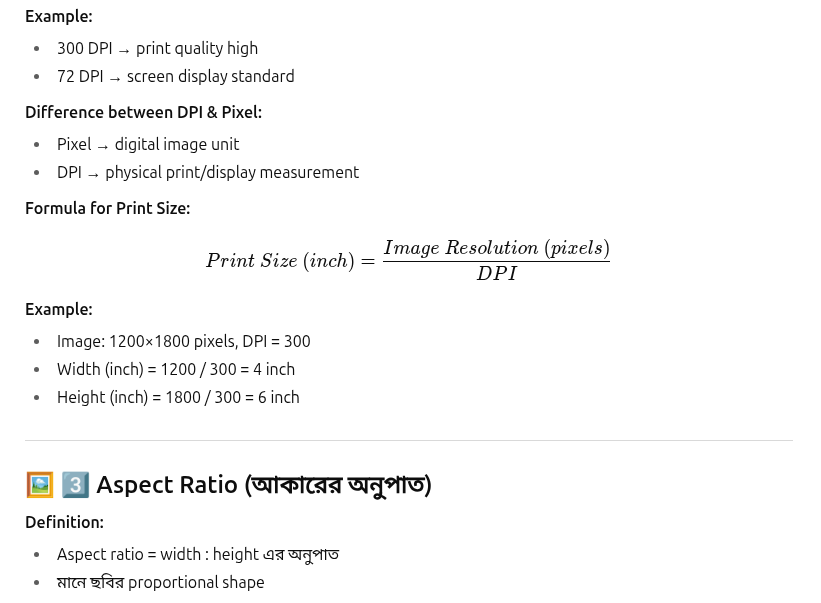

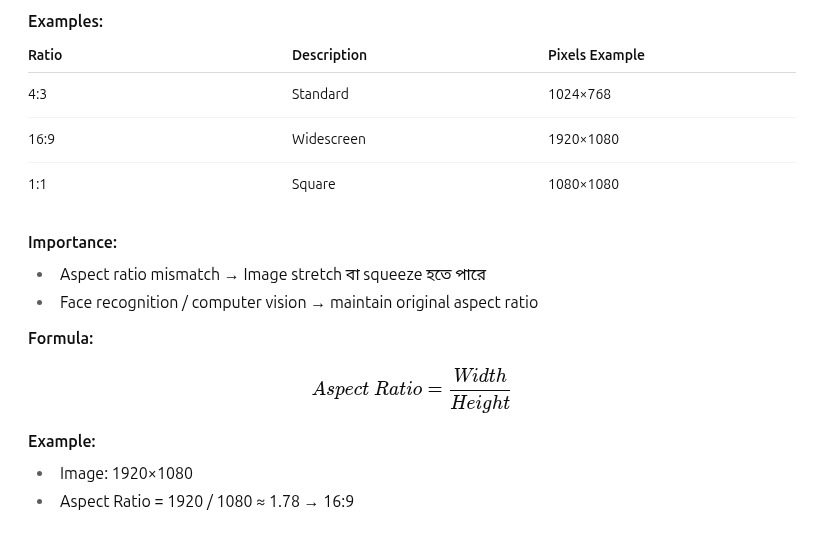

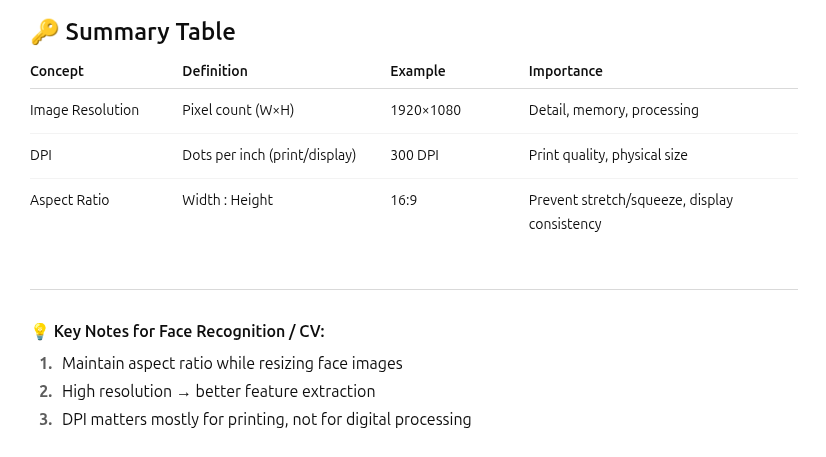

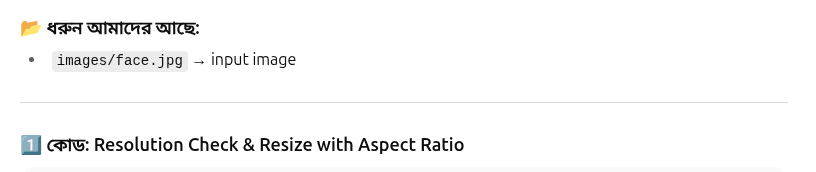

In [16]:
import cv2

# Load Image
image = cv2.imread("../dataset/test/ronaldo.jpg")
height, width, channels = image.shape

print(f"Original Resolution: {width}x{height} pixels")
print(f"Channels: {channels}")


# Desired width (maintain aspect ratio)
desired_width = 300
aspect_ratio = width / height
new_height = int(desired_width / aspect_ratio)

# Resize image
resized_image = cv2.resize(image, (desired_width, new_height))

print(f"Resized Resolution: {resized_image.shape[1]}x{resized_image.shape[0]} pixels")


# Show images
cv2.imshow("Original Image", image)
cv2.imshow("Resized Image", resized_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

Original Resolution: 300x390 pixels
Channels: 3
Resized Resolution: 300x390 pixels


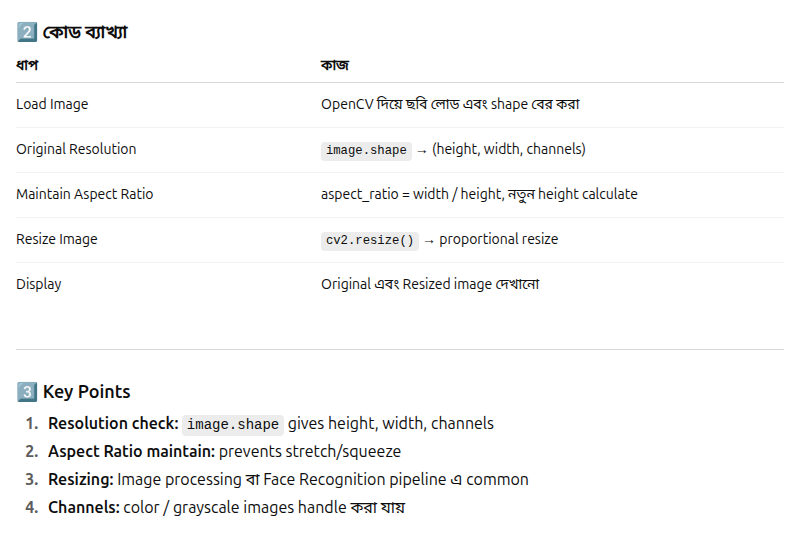

# 12. Image Scaling ও Resizing Concept

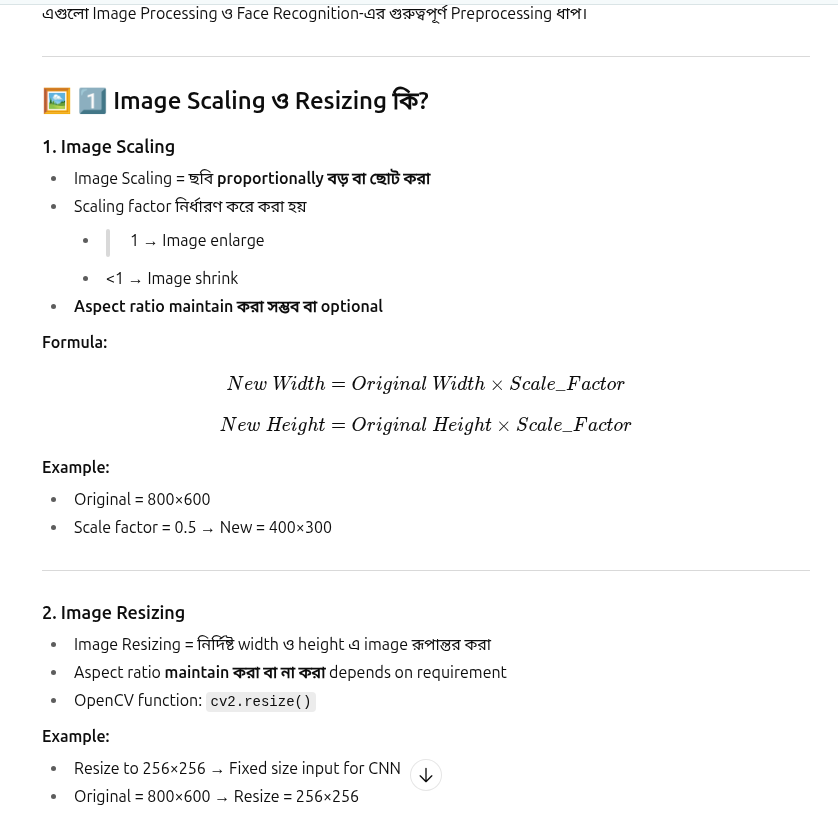

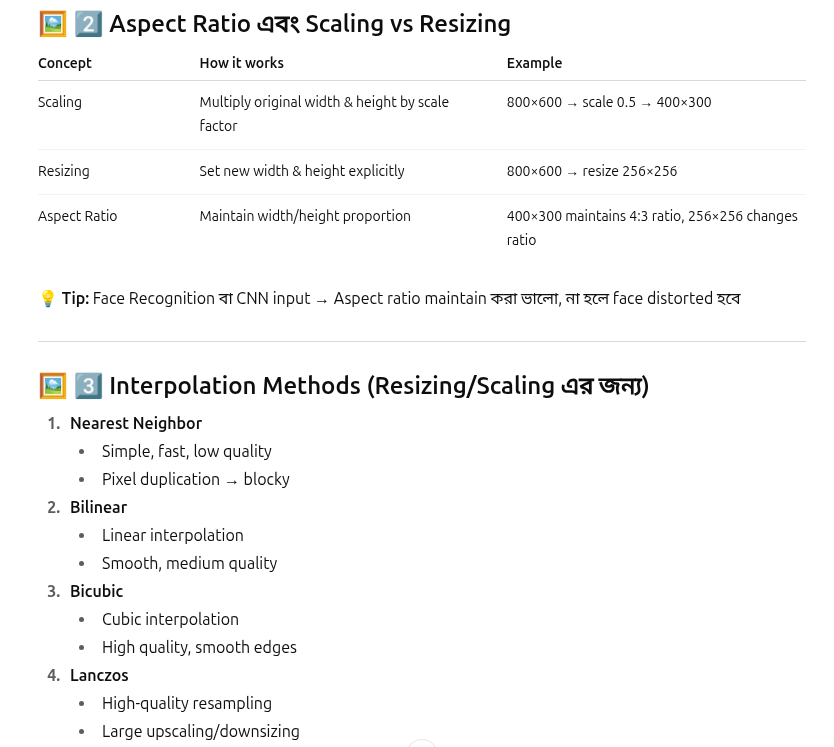

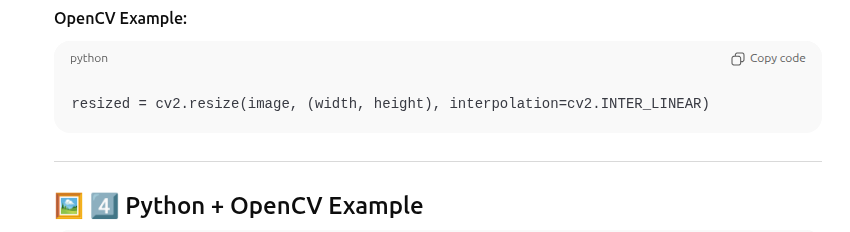

In [19]:
import cv2

# Load image
image = cv2.imread("../dataset/test/cummins.jpg")
height, width = image.shape[:2]
print("Original Resolution:", width, "x", height)

# 1. Scaling (factor 0.5)
scale_factor = 0.5
scaled_image = cv2.resize(image, (0,0), fx=scale_factor, fy=scale_factor)
print("Scaled Resolution:", scaled_image.shape[1], "x", scaled_image.shape[0])


# 2. Resizing (fixed size 256x256)
resized_image = cv2.resize(image, (256,256))
print("Resized Resolution:", resized_image.shape[1], "x", resized_image.shape[0])

# Display
cv2.imshow("Original", image)
cv2.imshow("Scaled", scaled_image)
cv2.imshow("Resized", resized_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

Original Resolution: 587 x 629
Scaled Resolution: 294 x 314
Resized Resolution: 256 x 256


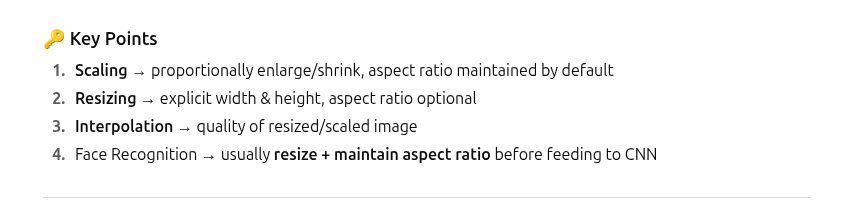

# 13. Image Resolution, Scaling, এবং Normalization

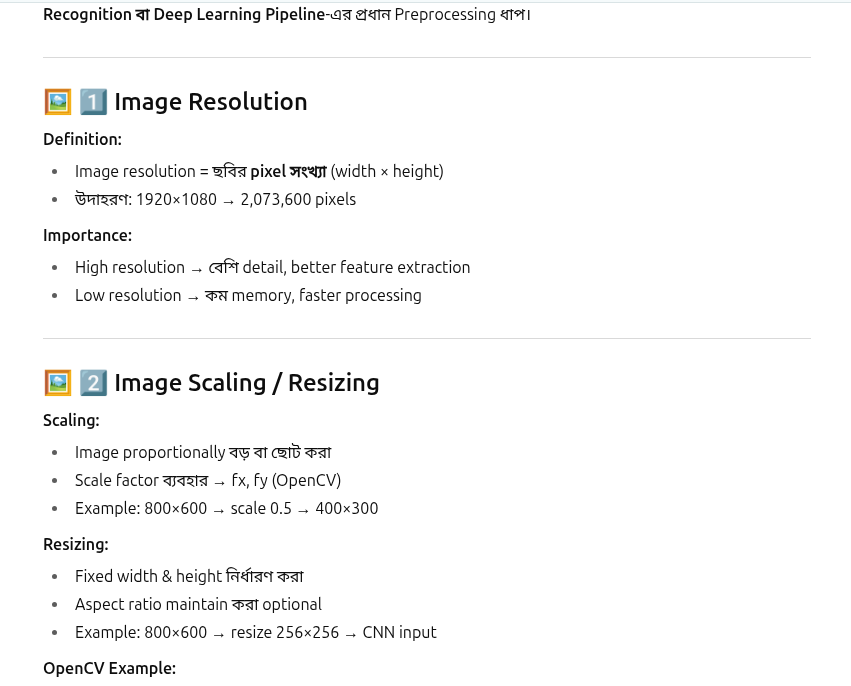

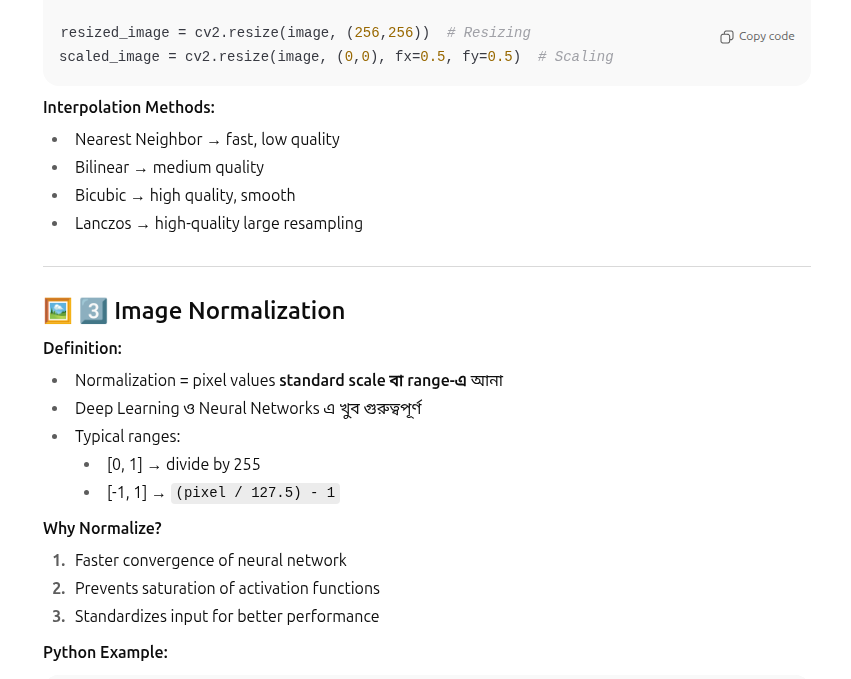

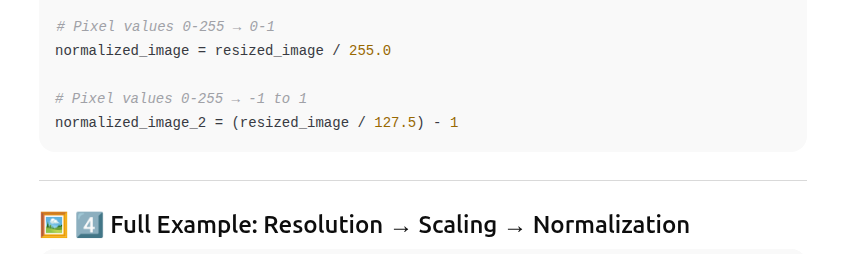

In [20]:
import cv2
import numpy as np

# Load image
image = cv2.imread("../dataset/test/ronaldo.jpg")
height, width = image.shape[:2]
print("Original Resolution:", width, "x", height)

# Resize to fixed size (CNN input)
resized_image = cv2.resize(image, (128,128))
print("Resized Resolution:", resized_image.shape[1], "x", resized_image.shape[0])

# Normalize pixel values to 0-1
normalized_image = resized_image / 255.0
print("Pixel range after normalization:", normalized_image.min(), "-", normalized_image.max())

Original Resolution: 300 x 390
Resized Resolution: 128 x 128
Pixel range after normalization: 0.0 - 0.9921568627450981


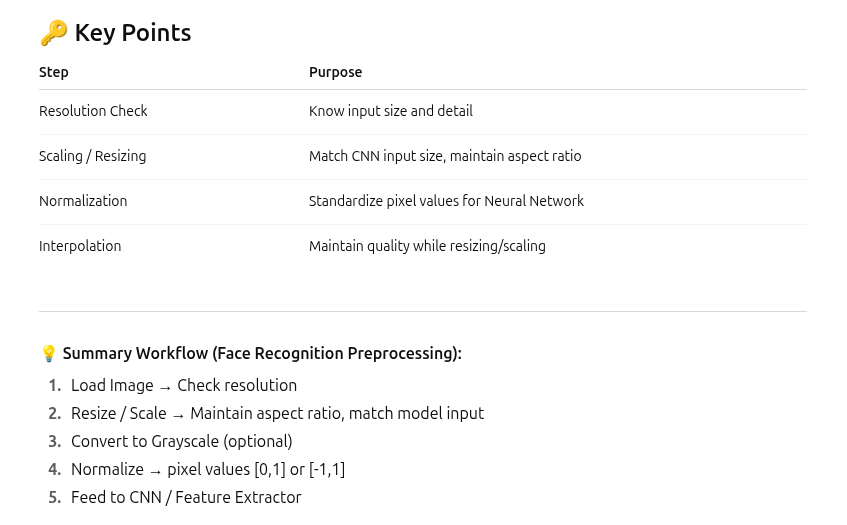

# 14. Dataset, Labels ও Annotation ধারণা

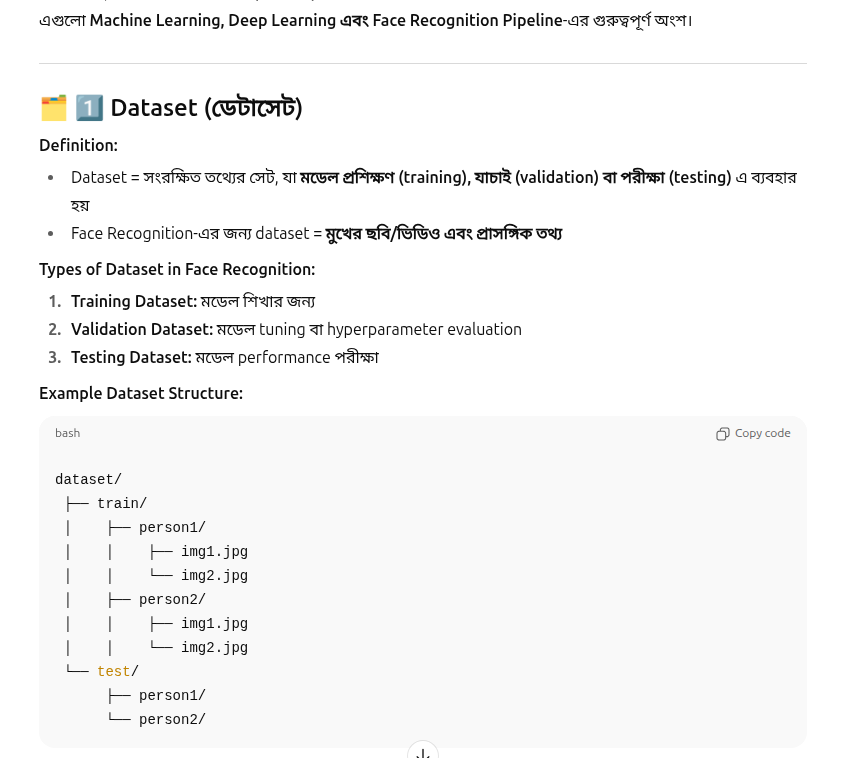

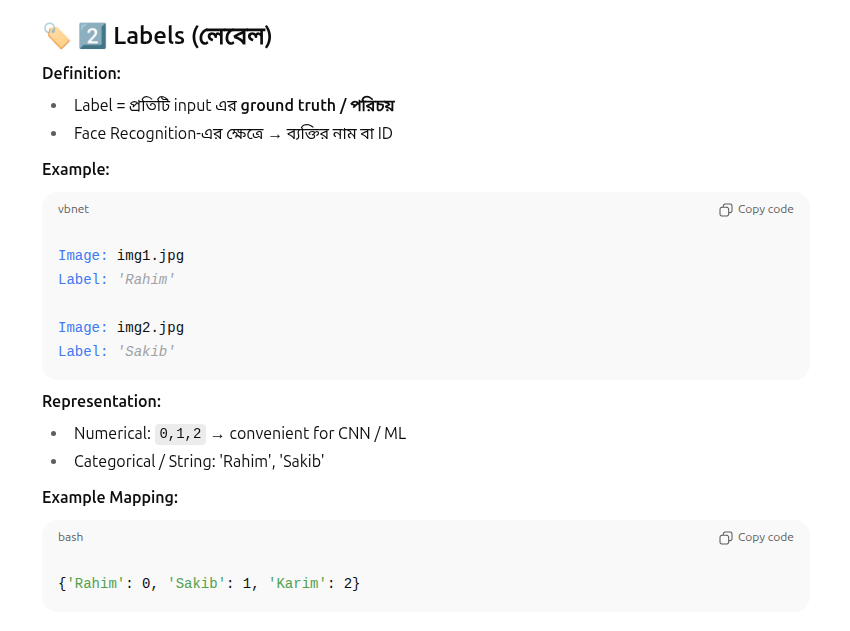

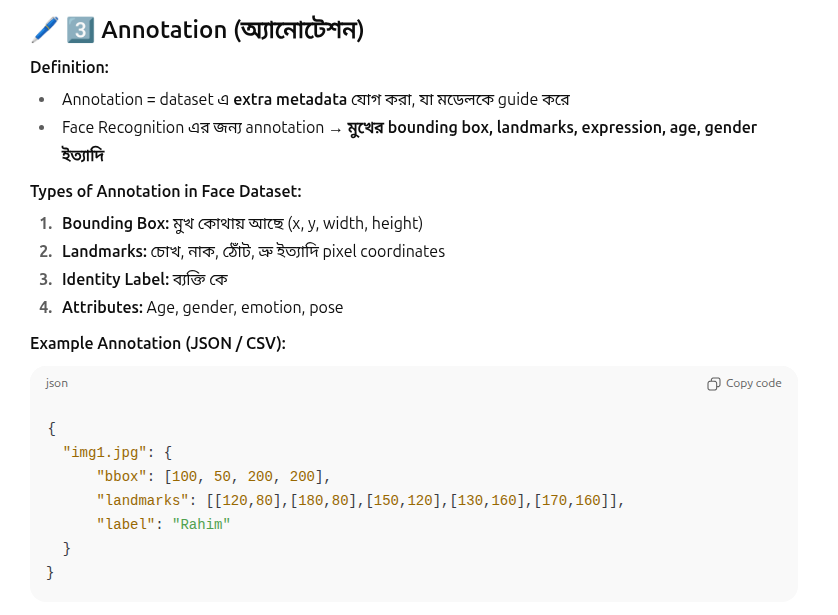

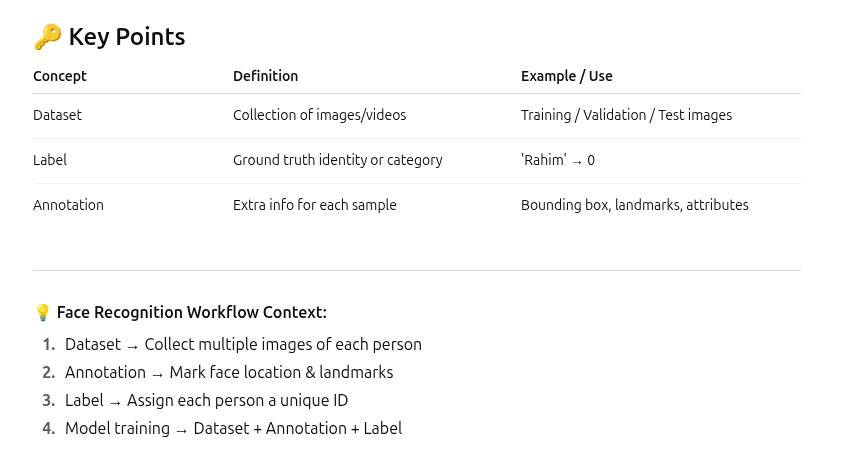

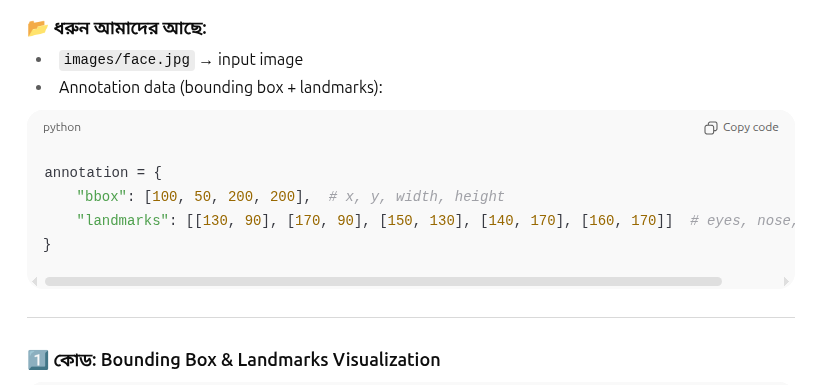

In [23]:
import cv2

# Load image
image = cv2.imread("../dataset/test/sinner.jpeg")

# Define annotation manually
annotation = {
    "bbox": [100, 50, 200, 200],  # x, y, width, height
    "landmarks": [
        [130, 90], [170, 90], [150, 130], [140, 170], [160, 170]  # eyes, nose, lips
    ]
}

# Draw bounding box
x, y, w, h = annotation["bbox"]
cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

# Draw landmarks
for (lx, ly) in annotation["landmarks"]:
    cv2.circle(image, (lx, ly), 3, (0, 0, 255), -1)

# Show image
cv2.imshow("Annotated Face", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

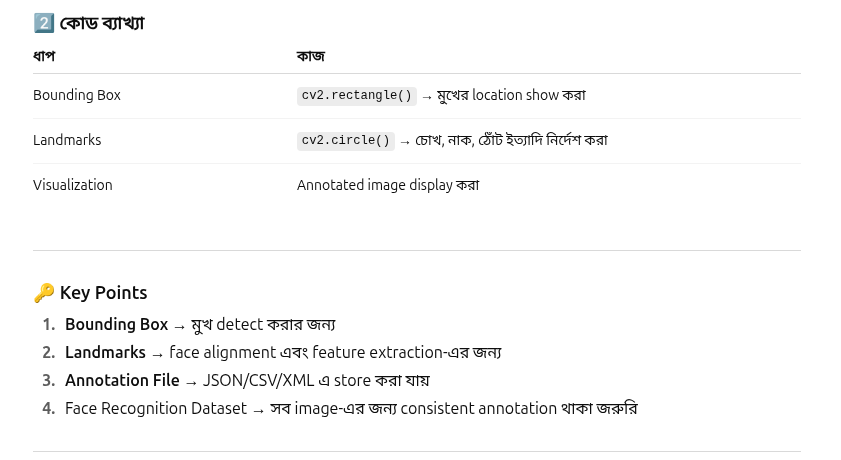